In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report
)

# Load data
df = pd.read_csv("../data/higgs_sample.csv")

# Separate features and target
X = df.drop(columns="target")
y = df["target"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (160000, 28)
Test set: (40000, 28)


In [2]:
rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


In [3]:
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

In [4]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

print("\nClassification report:")
print(classification_report(y_test, rf_pred))

Accuracy: 0.7235
Precision: 0.7327327327327328
Recall: 0.7504140052046369
ROC-AUC: 0.8015729206893878

Classification report:
              precision    recall  f1-score   support

         0.0       0.71      0.69      0.70     18865
         1.0       0.73      0.75      0.74     21135

    accuracy                           0.72     40000
   macro avg       0.72      0.72      0.72     40000
weighted avg       0.72      0.72      0.72     40000



In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Logistic Regression
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

In [9]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})
results.to_csv(
    r"C:\Users\yunac\OneDrive\Documents\GitHub\higgsmlproject\figures\model_comparison.csv",
    index=False
)
results

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.640675,0.638634,0.736929,0.682838
1,Random Forest,0.723500,0.732733,0.750414,0.801573


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(10))

m_bb                        0.112005
m_wwbb                      0.067986
m_wbb                       0.066057
m_jjj                       0.056578
m_jlv                       0.052002
jet1_pT                     0.051240
lepton_pT                   0.041591
m_jj                        0.039836
jet2_pT                     0.038817
missing_energy_magnitude    0.038410
dtype: float64


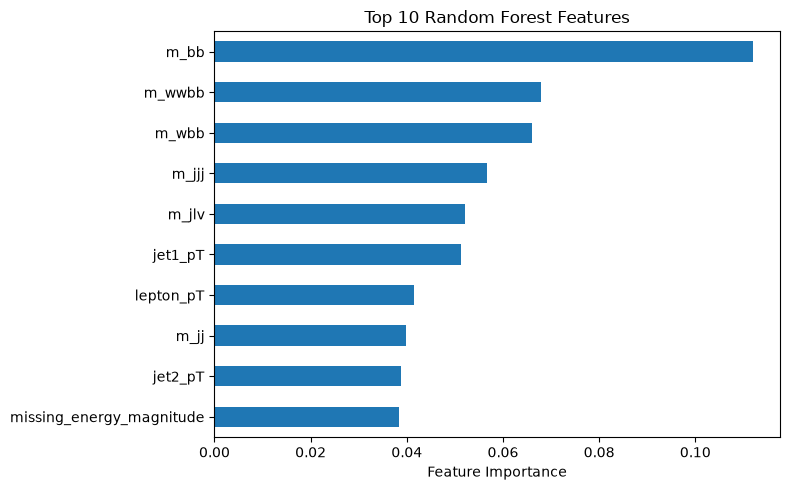

In [11]:
top_features = importance.head(10).sort_values()

top_features.plot(
    kind="barh",
    figsize=(8, 5)
)

plt.xlabel("Feature Importance")
plt.title("Top 10 Random Forest Features")
plt.tight_layout()

plt.savefig(
    r"C:\Users\yunac\OneDrive\Documents\GitHub\higgsmlproject\figures\random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
low_level_features = [
    "lepton_pT",
    "lepton_eta",
    "lepton_phi",
    "missing_energy_magnitude",
    "missing_energy_phi",
    "jet1_pT",
    "jet1_eta",
    "jet1_phi",
    "jet1_b_tag",
    "jet2_pT",
    "jet2_eta",
    "jet2_phi",
    "jet2_b_tag",
    "jet3_pT",
    "jet3_eta",
    "jet3_phi",
    "jet3_b_tag",
    "jet4_pT",
    "jet4_eta",
    "jet4_phi",
    "jet4_b_tag"
]
high_level_features = [
    "m_jj",
    "m_jjj",
    "m_lv",
    "m_jlv",
    "m_bb",
    "m_wbb",
    "m_wwbb"
]

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

X_low = df[low_level_features]
y = df["target"]

X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(
    X_low,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_low = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

rf_low.fit(X_train_low, y_train_low)

rf_low_prob = rf_low.predict_proba(X_test_low)[:, 1]

low_auc = roc_auc_score(y_test_low, rf_low_prob)

print("Low-level features ROC-AUC:", low_auc)

Low-level features ROC-AUC: 0.7013842405331521


In [16]:
print("All features ROC-AUC:", roc_auc_score(y_test, rf_prob))

All features ROC-AUC: 0.8015729206893878


In [18]:
feature_comparison = pd.DataFrame({
    "Feature Set": ["Low-level only", "All 28 features"],
    "ROC-AUC": [low_auc, roc_auc_score(y_test, rf_prob)]
})

feature_comparison.to_csv(
    r"C:\Users\yunac\OneDrive\Documents\GitHub\higgsmlproject\figures\feature_comparison.csv",
    index=False
)

feature_comparison

,Feature Set,ROC-AUC
0,Low-level only,0.701384
1,All 28 features,0.801573
